In [1]:
# ============================================================
#  Disease Symptom Classifier — Complete Pipeline
#  Dataset: Kaggle itachi9604/disease-symptom-description-dataset
#  Author: A Steve Isaiah | Amrita Coimbatore
# ============================================================
 
# ── 0. Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
 
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)
print("✅ Imports done.\n")

✅ Imports done.



In [25]:
# ── 1. Load Data ─────────────────────────────────────────────
print("=" * 60)
print("STEP 1 — Loading Training and Testing Data")
print("=" * 60)

train_df = pd.read_csv("Training.csv")
test_df  = pd.read_csv("Testing.csv")

# Clean column names and drop any unnamed column
train_df = train_df.loc[:, ~train_df.columns.str.contains('^Unnamed')]
test_df  = test_df.loc[:, ~test_df.columns.str.contains('^Unnamed')]

print(f"Training shape : {train_df.shape}")
print(f"Testing shape  : {test_df.shape}")
print(f"Number of symptoms : {train_df.shape[1] - 1}")
print(f"Number of diseases : {train_df['prognosis'].nunique()}")

STEP 1 — Loading Training and Testing Data
Training shape : (4920, 133)
Testing shape  : (42, 133)
Number of symptoms : 132
Number of diseases : 41


In [26]:
# ── 2. Preprocessing ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2 — Preprocessing")
print("=" * 60)

# Symptom columns (all except 'prognosis')
symptom_cols = [col for col in train_df.columns if col != 'prognosis']

# Ensure all symptom values are binary (0 or 1)
for col in symptom_cols:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce').fillna(0).astype(int)
    test_df[col]  = pd.to_numeric(test_df[col],  errors='coerce').fillna(0).astype(int)

# Encode target
le = LabelEncoder()
train_df['disease_encoded'] = le.fit_transform(train_df['prognosis'])
test_df['disease_encoded']  = le.transform(test_df['prognosis'])

X_train = train_df[symptom_cols]
y_train = train_df['disease_encoded']
X_test  = test_df[symptom_cols]
y_test  = test_df['disease_encoded']

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Classes       : {len(le.classes_)}")


STEP 2 — Preprocessing
X_train shape : (4920, 132)
X_test shape  : (42, 132)
Classes       : 41



STEP 3 — EDA Plots


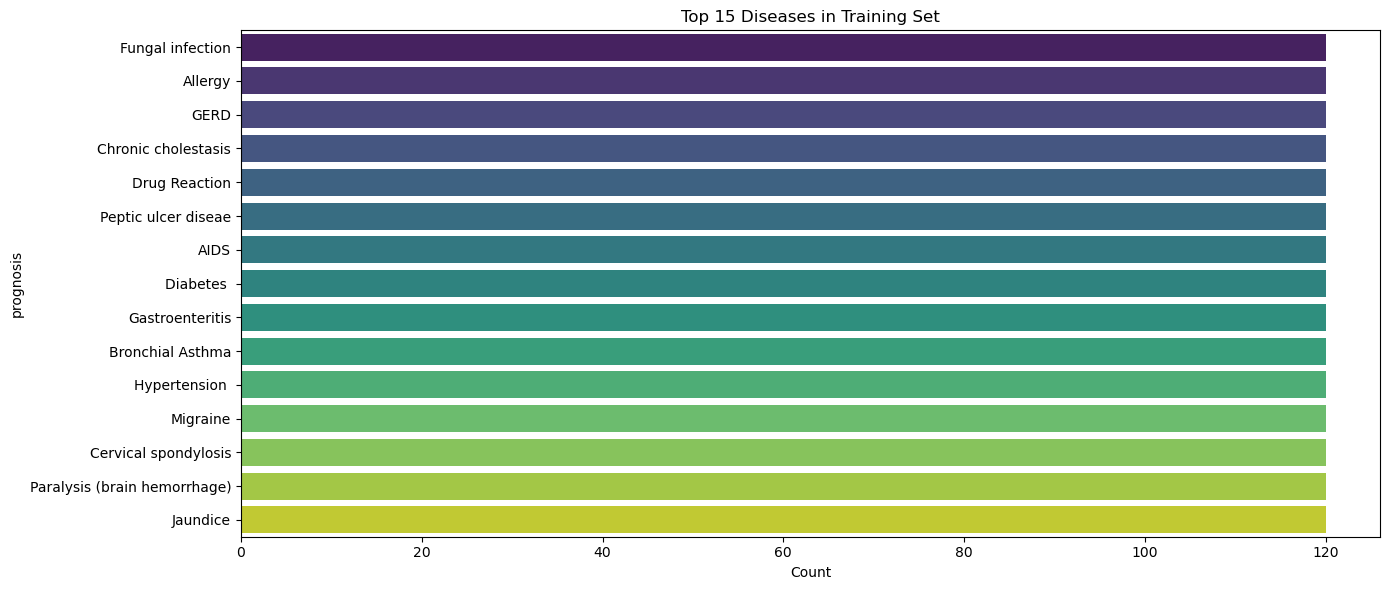

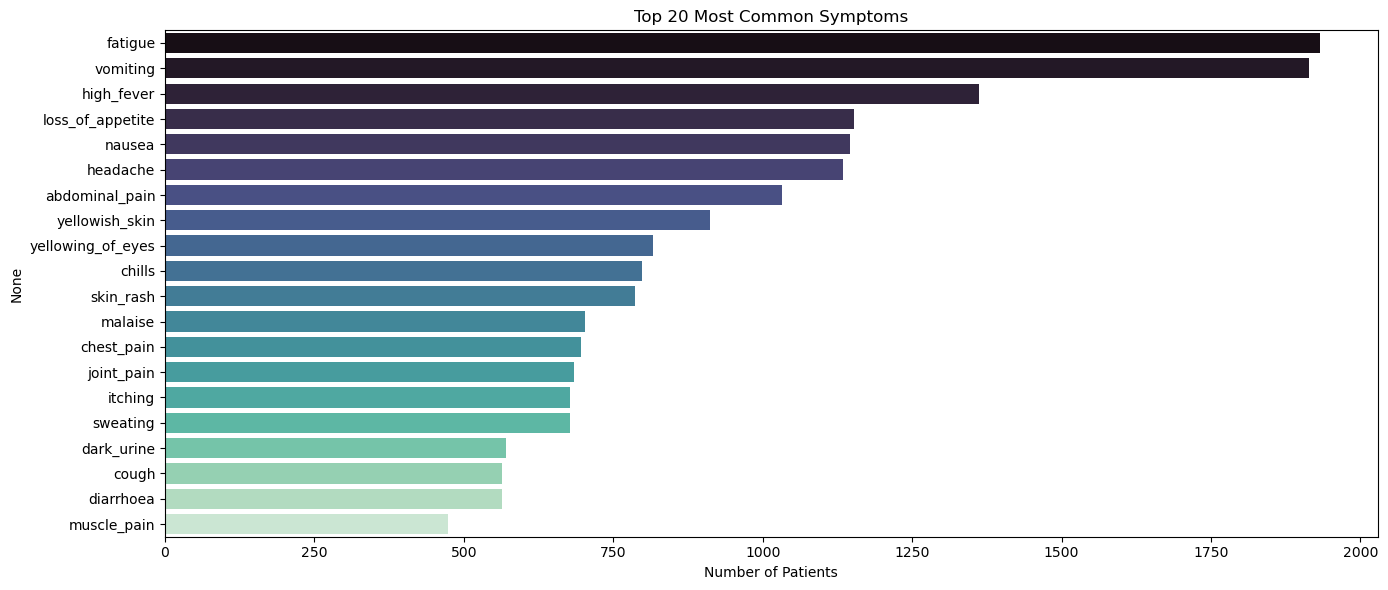

EDA plots saved in outputs/ folder.


In [27]:
# ── 3. EDA Plots ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3 — EDA Plots")
print("=" * 60)

plt.figure(figsize=(14, 6))
sns.barplot(y=train_df['prognosis'].value_counts().index[:15],
            x=train_df['prognosis'].value_counts().values[:15], palette="viridis")
plt.title("Top 15 Diseases in Training Set")
plt.xlabel("Count")
plt.tight_layout()
plt.show()
plt.savefig("outputs/01_disease_frequency.png", dpi=150)
plt.close()

symptom_freq = X_train.sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(14, 6))
sns.barplot(x=symptom_freq.values, y=symptom_freq.index, palette="mako")
plt.title("Top 20 Most Common Symptoms")
plt.xlabel("Number of Patients")
plt.tight_layout()
plt.savefig("outputs/02_symptom_frequency.png", dpi=150)
plt.show()
plt.close()
print("EDA plots saved in outputs/ folder.")

In [28]:
# ── 4. Baseline — Decision Tree ───────────────────────────────
print("\n" + "=" * 60)
print("STEP 4 — Baseline: Decision Tree")
print("=" * 60)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print(f"Decision Tree  — Test Acc: {dt_acc:.4f}")


STEP 4 — Baseline: Decision Tree
Decision Tree  — Test Acc: 0.9762


In [29]:
# ── 5. Random Forest ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5 — Random Forest")
print("=" * 60)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest  — Test Acc: {rf_acc:.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_pred, target_names=le.classes_, zero_division=0))


STEP 5 — Random Forest
Random Forest  — Test Acc: 0.9762

Classification Report (Random Forest):
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
          

In [30]:
# ── 6. Gradient Boosting ──────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 6 — Gradient Boosting")
print("=" * 60)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)

print(f"Gradient Boost — Test Acc: {gb_acc:.4f}")


STEP 6 — Gradient Boosting
Gradient Boost — Test Acc: 0.9762


In [31]:
# ── 7. Naive Bayes ───────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 7 — Naive Bayes")
print("=" * 60)

nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

print(f"Naive Bayes    — Test Acc: {nb_acc:.4f}")


STEP 7 — Naive Bayes
Naive Bayes    — Test Acc: 1.0000


In [32]:
# ── 8. Model Comparison ───────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 8 — Model Comparison")
print("=" * 60)

models = ["Decision Tree", "Random Forest", "Gradient Boosting", "Naive Bayes"]
accs = [dt_acc, rf_acc, gb_acc, nb_acc]

for m, a in zip(models, accs):
    print(f"{m:20} → Test Accuracy: {a:.4f} ({a*100:.2f}%)")

print(f"\n✅ Best Model: Random Forest with {rf_acc:.4f} accuracy")


STEP 8 — Model Comparison
Decision Tree        → Test Accuracy: 0.9762 (97.62%)
Random Forest        → Test Accuracy: 0.9762 (97.62%)
Gradient Boosting    → Test Accuracy: 0.9762 (97.62%)
Naive Bayes          → Test Accuracy: 1.0000 (100.00%)

✅ Best Model: Random Forest with 0.9762 accuracy


In [33]:
# ── 9. Save Model & Encoder ───────────────────────────────────
print("\n" + "=" * 60)
print("STEP 9 — Saving Model")
print("=" * 60)

joblib.dump(rf, "outputs/rf_disease_model.pkl")
joblib.dump(le, "outputs/label_encoder.pkl")
joblib.dump(symptom_cols, "outputs/symptom_columns.pkl")

print("Model and encoder saved successfully in outputs/ folder.")


STEP 9 — Saving Model
Model and encoder saved successfully in outputs/ folder.


In [34]:
# ── 10. Prediction Function ───────────────────────────────────
def predict_disease(symptoms_list, top_n=3):
    """Predict disease from list of symptoms"""
    input_vec = pd.Series(0, index=symptom_cols)
    for sym in symptoms_list:
        clean_sym = sym.strip().lower().replace(" ", "_").replace("-", "_")
        if clean_sym in input_vec.index:
            input_vec[clean_sym] = 1
    
    proba = rf.predict_proba([input_vec.values])[0]
    top_idx = np.argsort(proba)[::-1][:top_n]
    
    return [(le.classes_[i], round(proba[i]*100, 2)) for i in top_idx]

In [43]:
# ── 11. Quick Demo ────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 10 — Quick Demo")
print("=" * 60)

sample = ['chest_pain', 'breathlessness', 'sweating']
results = predict_disease(sample)
print(f"Symptoms: {sample}")
print("Predictions:")
for disease, prob in results:
    print(f"   {disease:<35} {prob:6.2f}%")


STEP 10 — Quick Demo
Symptoms: ['chest_pain', 'breathlessness', 'sweating']
Predictions:
   Heart attack                        100.00%
   Varicose veins                        0.00%
   Urinary tract infection               0.00%


In [38]:
predict_disease(['fever', 'cough', 'fatigue', 'headache'], top_n=3)
predict_disease(['chest_pain', 'breathlessness', 'sweating'], top_n=3)

[('Heart attack', np.float64(100.0)),
 ('Varicose veins', np.float64(0.0)),
 ('Urinary tract infection', np.float64(0.0))]